In [57]:
from __future__ import annotations

import os
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    median_absolute_error,
    mean_absolute_percentage_error,
)
from sklearn.model_selection import train_test_split

%matplotlib inline

BASE_PATH = Path("./onti-students-performance")
X_TRAIN_PATH = BASE_PATH / "X_train.csv"
X_TEST_PATH = BASE_PATH / "X_test.csv"
Y_TRAIN_PATH = BASE_PATH / "y_train.csv"
STUDS_INFO_PATH = BASE_PATH / "studs_info.csv"
SAMPLE_SUB_PATH = BASE_PATH / "sample_submission.csv"

missing = [str(p) for p in [X_TRAIN_PATH, X_TEST_PATH, Y_TRAIN_PATH, STUDS_INFO_PATH, SAMPLE_SUB_PATH] if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required data files:\n" + "\n".join(missing))

CPU_COUNT = os.cpu_count() or 1
N_JOBS = min(8, CPU_COUNT)
print(f"CPU_COUNT={CPU_COUNT}, N_JOBS={N_JOBS}")


CPU_COUNT=8, N_JOBS=8


In [61]:
def result_pred(pred, resY):
    print(f'mean_squared_error: {math.sqrt(mean_squared_error(resY, pred))}')
    print(f'mean_absolute_error: {mean_absolute_error(resY, pred)}')
    print(f'median_absolute_error: {median_absolute_error(resY, pred)}')
    print(f'mean_absolute_percentage_error: {mean_absolute_percentage_error(resY, pred)}')
    print(f'r2_score: {r2_score(resY, pred)}')

In [62]:
def result_value(pred, resY):
    return [math.sqrt(mean_squared_error(resY, pred)),
            mean_absolute_error(resY, pred),
            median_absolute_error(resY, pred),
            mean_absolute_percentage_error(resY, pred),
            r2_score(resY, pred)]

In [63]:
def result_table(args, resY, subcol=None, valueSubCol=None):
    if subcol and valueSubCol:
        dt = {subcol: valueSubCol,
            'mean_squared_error': [],
            'mean_absolute_error': [],
            'median_absolute_error': [],
            'mean_absolute_percentage_error': [],
            'r2_score': []}
    else:
        dt = {'mean_squared_error': [],
            'mean_absolute_error': [],
            'median_absolute_error': [],
            'mean_absolute_percentage_error': [],
            'r2_score': []}
    preds = args
    for pred in preds:
        tmp = result_value(pred, resY)
        dt['mean_squared_error'].append(tmp[0])
        dt['mean_absolute_error'].append(tmp[1])
        dt['median_absolute_error'].append(tmp[2])
        dt['mean_absolute_percentage_error'].append(tmp[3])
        dt['r2_score'].append(tmp[4])
    return dt

# Анализ данных

In [64]:
data = pd.read_csv(X_TRAIN_PATH)
if "Unnamed: 0" in data.columns:
    data = data.drop(columns=["Unnamed: 0"])

In [65]:
data

,STD_ID,НАПРАВЛЕНИЕ,ГОД,КУРС,СЕМЕСТР,АТТЕСТАЦИЯ,ДИСЦИПЛИНА
0,175711,38.03.02 Менеджмент,2018-2019,2.0,4.0,Экзамен,Маркетинг
1,100647,31.05.01 Лечебное дело,2015-2016,3.0,5.0,Экзамен,"Пропедевтика внутренних болезней, лучевая диаг..."
2,199311,31.05.03 Стоматология,2019-2020,1.0,1.0,Экзамен,Химия
3,162002,38.03.02 Менеджмент,2017-2018,2.0,3.0,Экзамен,Статистика
4,108384,31.05.01 Лечебное дело,2018-2019,5.0,9.0,Экзамен,Педиатрия
...,...,...,...,...,...,...,...
105053,176141,40.03.01 Юриспруденция,2017-2018,1.0,2.0,Курсовая работа,Конституционное право
105054,182794,31.05.01 Лечебное дело,2018-2019,2.0,4.0,Экзамен,Нормальная физиология
105055,162391,31.05.01 Лечебное дело,2016-2017,1.0,2.0,Дифференцированный зачет,Иностранный язык
105056,202479,38.03.01 Экономика,2017-2018,1.0,1.0,Дифференцированный зачет,Информатика


In [66]:
studs_info = pd.read_csv('./onti-students-performance/studs_info.csv').rename(columns={'   ': 'number2', '   number': 'number1'})

In [67]:
studs_info

,STD_ID,number1,Пол,Статус,Дата выпуска,Категория обучения,Форма обучения,Шифр,направление (специальность),number2,Образование,Дата выдачи,Что именно закончил
0,99136,13951.0,Ж,ВЫП,2019-08-31,БП,Д,31.05.01,Лечебное дело,2629.0,СР,2013-06-26 00:00:00,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
1,99112,13998.0,Ж,ВЫП,2019-08-31,БП,Д,31.05.01,Лечебное дело,8240.0,СР,2012-06-23 00:00:00,"МОУ СОШ N 2, ПЕСТОВО"
2,99109,13999.0,Ж,ВЫП,2019-08-31,БП,Д,31.05.01,Лечебное дело,2314.0,СР,2013-06-25 00:00:00,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
3,99125,13953.0,Ж,ВЫП,2019-08-31,БП,Д,31.05.01,Лечебное дело,2345.0,СР,2013-06-23 00:00:00,"Гимназия ""ГАРМОНИЯ"""
4,100676,13950.0,М,ВЫП,2019-08-31,БП,Д,31.05.01,Лечебное дело,2650.0,СР,2012-06-29 00:00:00,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5461,100678,978.0,Ж,СТ,NaN,БП,Д,31.05.01,Лечебное дело,2388.0,СР,2013-06-21 00:00:00,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
5462,100663,1021.0,Ж,СТ,NaN,ДОГ,Д,31.05.01,Лечебное дело,2554.0,СР,2013-06-27 00:00:00,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
5463,191630,6447.0,Ж,СТ,NaN,ДОГ,Д,31.05.01,Лечебное дело,6692.0,СР,2014-05-31 00:00:00,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
5464,191625,3765.0,Ж,СТ,NaN,ДОГ,Д,31.05.01,Лечебное дело,NaN,NaN,NaN,NaN


In [68]:
studs_info[studs_info['STD_ID'] == 149499]

,STD_ID,number1,Пол,Статус,Дата выпуска,Категория обучения,Форма обучения,Шифр,направление (специальность),number2,Образование,Дата выдачи,Что именно закончил
5106,149499,187.0,Ж,СТ,NaN,ДОГ,З,42.03.02,Журналистика,311.0,СР,2006-06-25 00:00:00,Панковская СОШ НОВГОРОДСКИЙ р-н
5107,149499,187.0,Ж,СТ,NaN,ДОГ,З,42.03.02,Журналистика,316.0,СР,NaN,"СРЕДНЯЯ ШКОЛА N 4, НОВГОРОД"
5108,149499,187.0,Ж,СТ,NaN,ДОГ,З,42.03.02,Журналистика,9542.0,СП,2008-06-27 00:00:00,Аграрный техникум г.Новгород


In [69]:
studs_info.isnull().sum()

STD_ID                            0
number1                           1
Пол                               1
Статус                            1
Дата выпуска                   5002
Категория обучения                1
Форма обучения                    1
Шифр                              1
направление (специальность)       1
number2                         191
Образование                     191
Дата выдачи                     240
Что именно закончил             191
dtype: int64

In [70]:
studs_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5466 entries, 0 to 5465
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   STD_ID                       5466 non-null   int64  
 1   number1                      5465 non-null   float64
 2   Пол                          5465 non-null   object 
 3   Статус                       5465 non-null   object 
 4   Дата выпуска                 464 non-null    object 
 5   Категория обучения           5465 non-null   object 
 6   Форма обучения               5465 non-null   object 
 7   Шифр                         5465 non-null   object 
 8   направление (специальность)  5465 non-null   object 
 9   number2                      5275 non-null   float64
 10  Образование                  5275 non-null   object 
 11  Дата выдачи                  5226 non-null   object 
 12  Что именно закончил          5275 non-null   object 
dtypes: float64(2), int

In [71]:
studs_info = studs_info.drop(columns=['Дата выпуска', 'Шифр', 'направление (специальность)', 'Дата выдачи'])

In [72]:
studs_info.isnull().sum()

STD_ID                   0
number1                  1
Пол                      1
Статус                   1
Категория обучения       1
Форма обучения           1
number2                191
Образование            191
Что именно закончил    191
dtype: int64

In [73]:
studs_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5466 entries, 0 to 5465
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   STD_ID               5466 non-null   int64  
 1   number1              5465 non-null   float64
 2   Пол                  5465 non-null   object 
 3   Статус               5465 non-null   object 
 4   Категория обучения   5465 non-null   object 
 5   Форма обучения       5465 non-null   object 
 6   number2              5275 non-null   float64
 7   Образование          5275 non-null   object 
 8   Что именно закончил  5275 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 384.5+ KB


In [74]:
studs_info

,STD_ID,number1,Пол,Статус,Категория обучения,Форма обучения,number2,Образование,Что именно закончил
0,99136,13951.0,Ж,ВЫП,БП,Д,2629.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
1,99112,13998.0,Ж,ВЫП,БП,Д,8240.0,СР,"МОУ СОШ N 2, ПЕСТОВО"
2,99109,13999.0,Ж,ВЫП,БП,Д,2314.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
3,99125,13953.0,Ж,ВЫП,БП,Д,2345.0,СР,"Гимназия ""ГАРМОНИЯ"""
4,100676,13950.0,М,ВЫП,БП,Д,2650.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
...,...,...,...,...,...,...,...,...,...
5461,100678,978.0,Ж,СТ,БП,Д,2388.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
5462,100663,1021.0,Ж,СТ,ДОГ,Д,2554.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
5463,191630,6447.0,Ж,СТ,ДОГ,Д,6692.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
5464,191625,3765.0,Ж,СТ,ДОГ,Д,NaN,NaN,NaN


In [75]:
studs_info['STD_ID'].value_counts()

STD_ID
182225    3
149499    3
176688    3
164799    3
171774    3
         ..
189770    1
188657    1
195160    1
194832    1
188959    1
Name: count, Length: 5104, dtype: int64

In [84]:
studs_info = studs_info.drop_duplicates(['STD_ID']).copy()

In [85]:
studs_info['number1'] = studs_info['number1'].fillna(studs_info['number1'].mean())
studs_info['Пол'] = studs_info['Пол'].fillna(studs_info['Пол'].value_counts().index[0])
studs_info['Статус'] = studs_info['Статус'].fillna(studs_info['Статус'].value_counts().index[0])
studs_info['Категория обучения'] = studs_info['Категория обучения'].fillna(studs_info['Категория обучения'].value_counts().index[0])
studs_info['Форма обучения'] = studs_info['Форма обучения'].fillna(studs_info['Форма обучения'].value_counts().index[0])
studs_info['number2'] = studs_info['number2'].fillna(studs_info['number2'].mean())
studs_info['Образование'] = studs_info['Образование'].fillna(studs_info['Образование'].value_counts().index[0])
studs_info['Что именно закончил'] = studs_info['Что именно закончил'].fillna(studs_info['Что именно закончил'].value_counts().index[0])

In [86]:
studs_info.isnull().sum()

STD_ID                 0
number1                0
Пол                    0
Статус                 0
Категория обучения     0
Форма обучения         0
number2                0
Образование            0
Что именно закончил    0
dtype: int64

In [87]:
pd.read_csv('./onti-students-performance/studs_info.csv')['STD_ID'].unique()

array([ 99136,  99112,  99109, ..., 191630, 191625, 194978], shape=(5104,))

In [88]:
data['STD_ID'].unique()

array([175711, 100647, 199311, ..., 162272, 200391, 194047], shape=(5084,))

In [89]:
data = data.merge(studs_info, how='left', on='STD_ID').dropna()

In [90]:
data

,STD_ID,НАПРАВЛЕНИЕ,ГОД,КУРС,СЕМЕСТР,АТТЕСТАЦИЯ,ДИСЦИПЛИНА,number1,Пол,Статус,Категория обучения,Форма обучения,number2,Образование,Что именно закончил
0,175711,38.03.02 Менеджмент,2018-2019,2.0,4.0,Экзамен,Маркетинг,3989.0,М,СТ,БП,Д,5445.0,СР,"СРЕДНЯЯ ШКОЛА N 31, НОВГОРОД"
1,100647,31.05.01 Лечебное дело,2015-2016,3.0,5.0,Экзамен,"Пропедевтика внутренних болезней, лучевая диаг...",14025.0,Ж,ВЫП,ДОГ,Д,2668.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
2,199311,31.05.03 Стоматология,2019-2020,1.0,1.0,Экзамен,Химия,7212.0,Ж,СТ,БП,Д,11431.0,СР,"ГИМНАЗИЯ N 2, НОВГОРОД"
3,162002,38.03.02 Менеджмент,2017-2018,2.0,3.0,Экзамен,Статистика,3293.0,М,СТ,БП,Д,4981.0,СР,"Гимназия ""ГАРМОНИЯ"""
4,108384,31.05.01 Лечебное дело,2018-2019,5.0,9.0,Экзамен,Педиатрия,875.0,Ж,СТ,ДОГ,Д,2034.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105053,176141,40.03.01 Юриспруденция,2017-2018,1.0,2.0,Курсовая работа,Конституционное право,861.0,Ж,СТ,ДОГ,В,8613.0,СР,"МОУ СОШ N 1, СОЛЬЦЫ с филиалом в Куклино"
105054,182794,31.05.01 Лечебное дело,2018-2019,2.0,4.0,Экзамен,Нормальная физиология,3859.0,Ж,СТ,ДОГ,Д,5505.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
105055,162391,31.05.01 Лечебное дело,2016-2017,1.0,2.0,Дифференцированный зачет,Иностранный язык,6989.0,Ж,СТ,БП,Д,4900.0,СР,"ГИМНАЗИЯ N 1, НОВГОРОД"
105056,202479,38.03.01 Экономика,2017-2018,1.0,1.0,Дифференцированный зачет,Информатика,4091.0,Ж,СТ,ДОГ,З,5466.0,СР,"Гимназия ""ГАРМОНИЯ"""


In [91]:
pd.read_csv('./onti-students-performance/y_train.csv')

,index,mark
0,51081,5
1,72921,5
2,96438,5
3,273044,4
4,371309,3
...,...,...
105053,224856,3
105054,260998,3
105055,57245,4
105056,218529,4


In [93]:
data.isnull().sum()

STD_ID                 0
НАПРАВЛЕНИЕ            0
ГОД                    0
КУРС                   0
СЕМЕСТР                0
АТТЕСТАЦИЯ             0
ДИСЦИПЛИНА             0
number1                0
Пол                    0
Статус                 0
Категория обучения     0
Форма обучения         0
number2                0
Образование            0
Что именно закончил    0
dtype: int64

In [94]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105058 entries, 0 to 105057
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   STD_ID               105058 non-null  int64  
 1   НАПРАВЛЕНИЕ          105058 non-null  object 
 2   ГОД                  105058 non-null  object 
 3   КУРС                 105058 non-null  float64
 4   СЕМЕСТР              105058 non-null  float64
 5   АТТЕСТАЦИЯ           105058 non-null  object 
 6   ДИСЦИПЛИНА           105058 non-null  object 
 7   number1              105058 non-null  float64
 8   Пол                  105058 non-null  object 
 9   Статус               105058 non-null  object 
 10  Категория обучения   105058 non-null  object 
 11  Форма обучения       105058 non-null  object 
 12  number2              105058 non-null  float64
 13  Образование          105058 non-null  object 
 14  Что именно закончил  105058 non-null  object 
dtypes: float64(4), in

In [95]:
data.shape

(105058, 15)

In [96]:
data.drop_duplicates().shape

(105058, 15)

In [97]:
data = data.drop_duplicates()

## Котегориальные признаки

In [98]:
def plot_categorical_pie(
    df,
    column,
    title,
    *,
    figsize=(11, 7),
    top_n=6,
    min_pct_other=1.5,
    other_label="Прочее",
    label_max_chars=40,
    donut=True,
):
    min_pct_autopct = 4.0

    counts = df[column].value_counts(dropna=False)
    counts = counts[counts > 0]
    total = int(counts.sum())
    n_cat_total = len(counts)

    def fmt_cat(x):
        if pd.isna(x):
            return "(пусто)"
        return str(x)

    def trunc_label(lab):
        if isinstance(lab, str) and lab.startswith(other_label):
            s = lab
        else:
            s = fmt_cat(lab)
        if len(s) <= label_max_chars:
            return s
        return s[: label_max_chars - 1] + "…"

    working = []
    if n_cat_total > top_n + 1:
        for idx, val in counts.iloc[:top_n].items():
            working.append((idx, val))
        tail_sum = counts.iloc[top_n:].sum()
        tail_n_cats = n_cat_total - top_n
        working.append(("__TAIL__", tail_sum, tail_n_cats))
    else:
        for idx, val in counts.items():
            working.append((idx, val))

    other_sum = 0
    other_n_cats = 0
    final_parts = []

    for w in working:
        if len(w) == 3 and w[0] == "__TAIL__":
            other_sum += w[1]
            other_n_cats += w[2]
            continue
        idx, val = w[0], w[1]
        pct = 100.0 * val / total if total else 0.0
        if pct < min_pct_other:
            other_sum += val
            other_n_cats += 1
        else:
            final_parts.append((idx, val))

    if other_sum > 0:
        final_parts.append((f"{other_label} ({other_n_cats} кат.)", other_sum))

    final_parts.sort(key=lambda x: x[1], reverse=True)

    labels_idx = [p[0] for p in final_parts]
    sizes = np.array([p[1] for p in final_parts], dtype=float)

    base_palette = sns.color_palette("Set2", n_colors=max(len(labels_idx), 3))
    colors = []
    ci = 0
    for lab in labels_idx:
        if isinstance(lab, str) and lab.startswith(other_label):
            colors.append("#bdbdbd")
        else:
            colors.append(base_palette[ci % len(base_palette)])
            ci += 1

    def autopct(pct):
        return f"{pct:.0f}%" if pct >= min_pct_autopct else ""

    wedgeprops = {"edgecolor": "white", "linewidth": 1}
    if donut:
        wedgeprops["width"] = 0.45

    fig, ax = plt.subplots(figsize=figsize)
    wedges, _texts, autotexts = ax.pie(
        sizes,
        autopct=autopct,
        startangle=90,
        counterclock=False,
        colors=colors,
        wedgeprops=wedgeprops,
        pctdistance=0.78 if donut else 0.72,
    )
    for t in autotexts:
        if t.get_text() == "":
            t.set_visible(False)
        else:
            t.set_fontsize(9)

    if donut and total:
        ax.text(0, 0, f"N = {total:,}".replace(",", " "), ha="center", va="center", fontsize=11)

    legend_entries = [
        f"{trunc_label(lab)} — {int(cnt):,}".replace(",", " ")
        + f" ({100 * cnt / total:.1f}%)"
        for lab, cnt in zip(labels_idx, sizes)
    ]
    ax.legend(
        wedges,
        legend_entries,
        title=f"Категория (всего {n_cat_total})",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=11,
        title_fontsize=12,
        labelspacing=0.65,
        handlelength=1.3,
        handletextpad=0.7,
    )
    ax.set_title(title)
    ax.axis("equal")
    fig.tight_layout()
    plt.show()


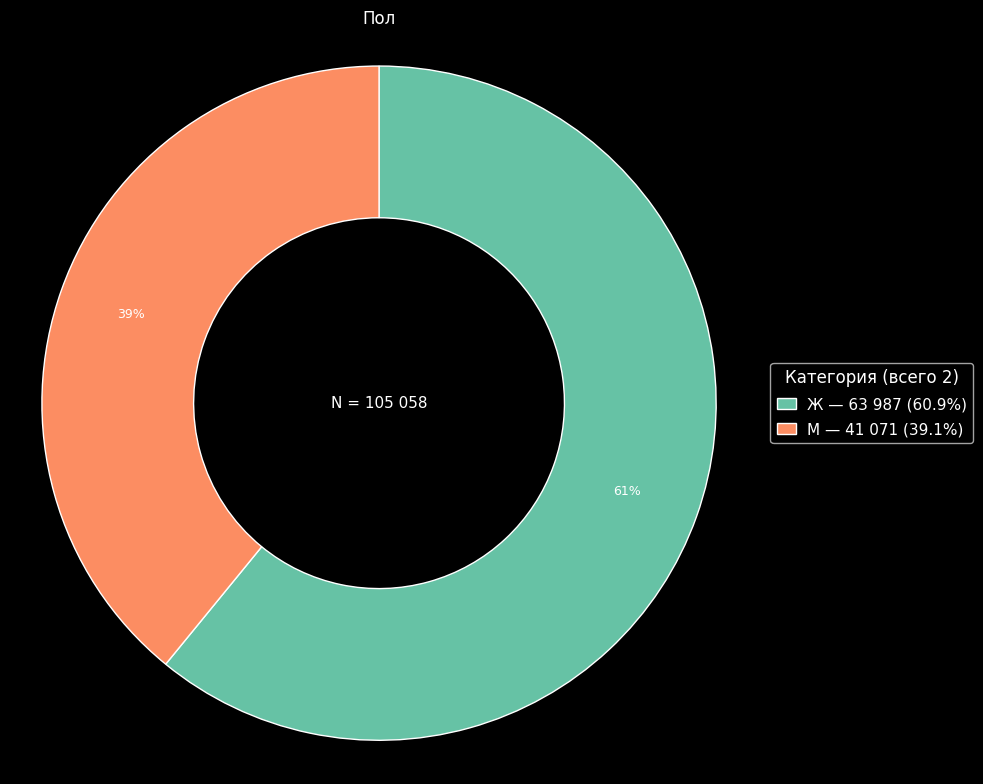

In [100]:
plot_categorical_pie(data, "Пол", "Пол", figsize=(10, 8))


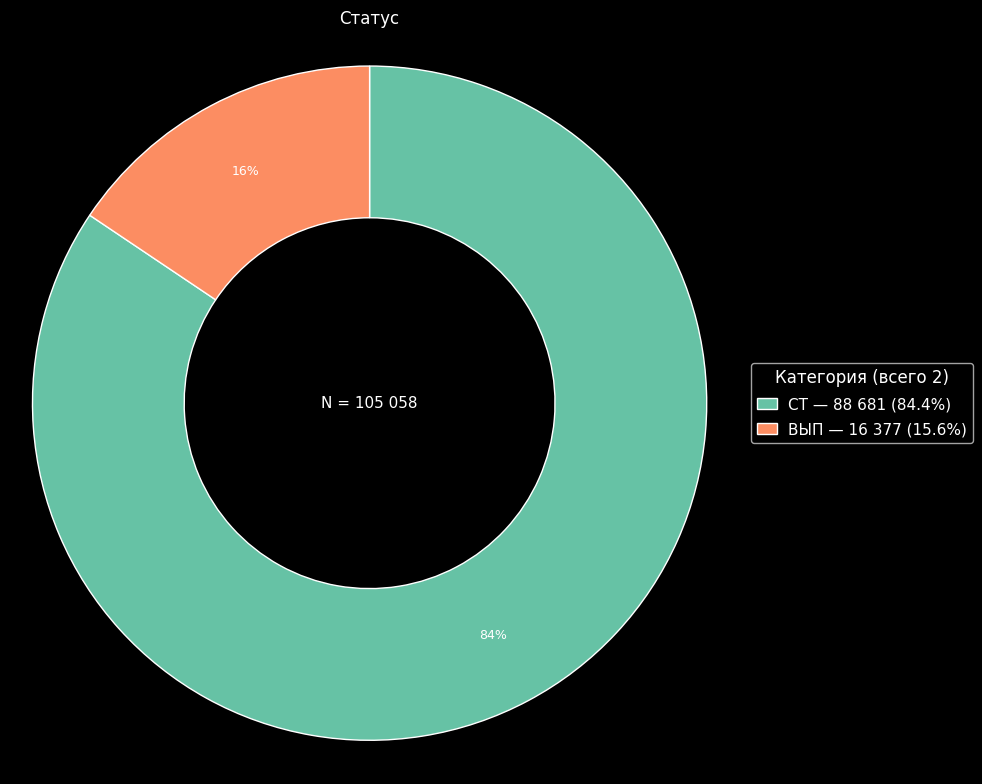

In [101]:
plot_categorical_pie(data, "Статус", "Статус", figsize=(10, 8))


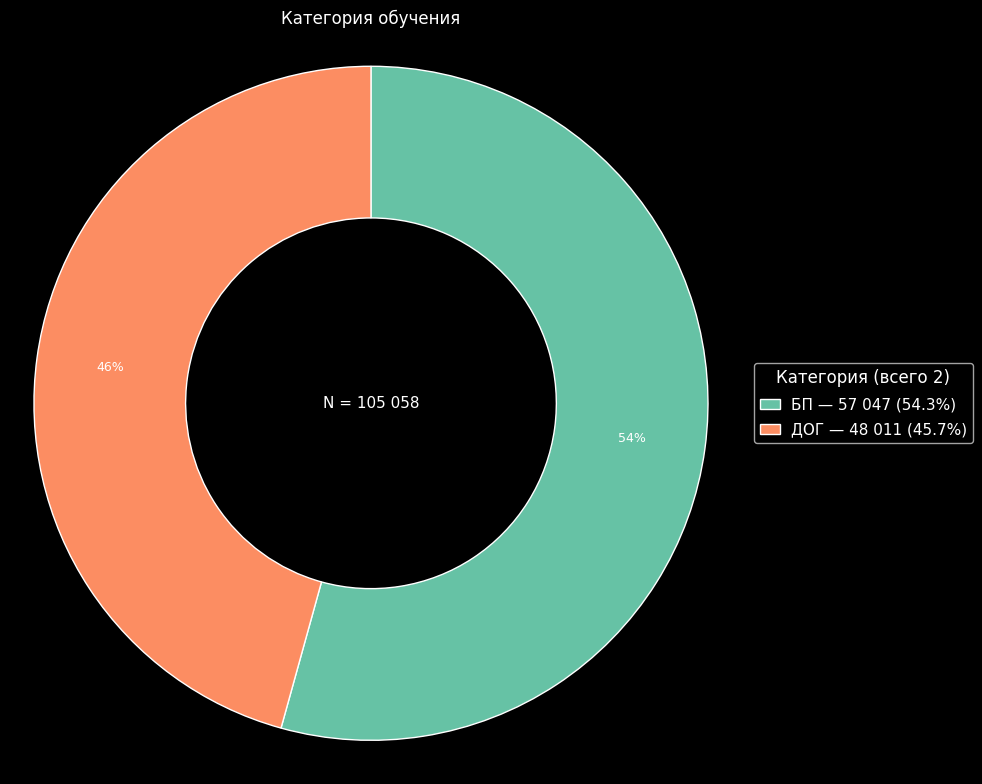

In [102]:
plot_categorical_pie(data, "Категория обучения", "Категория обучения", figsize=(10, 8))


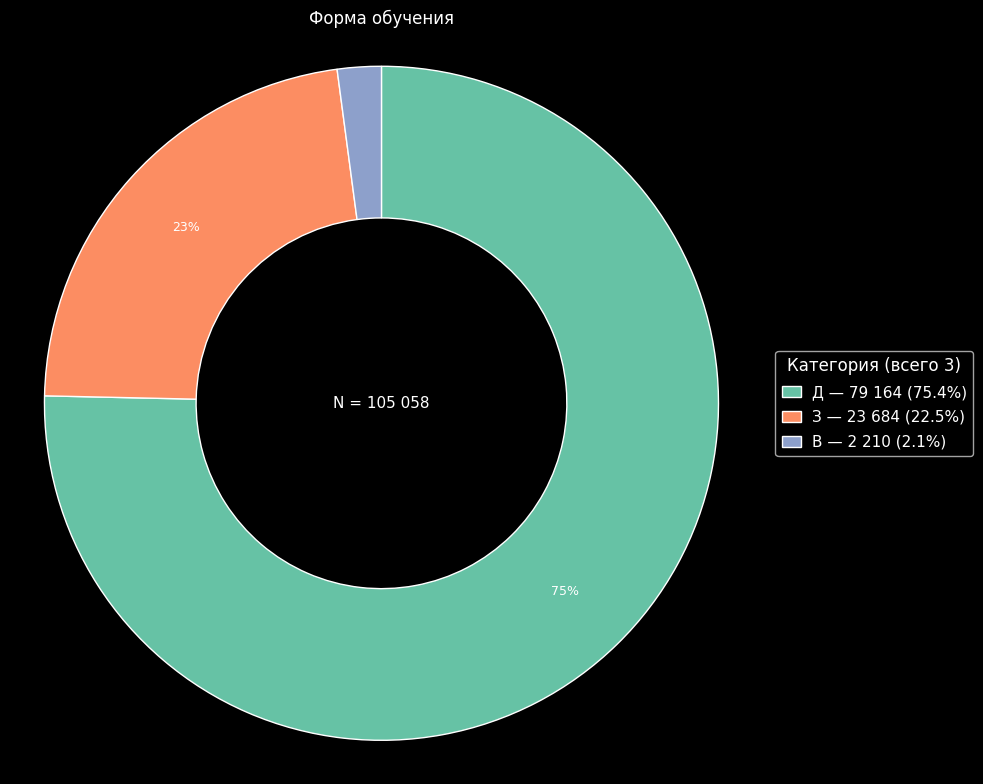

In [103]:
plot_categorical_pie(data, "Форма обучения", "Форма обучения", figsize=(10, 8))


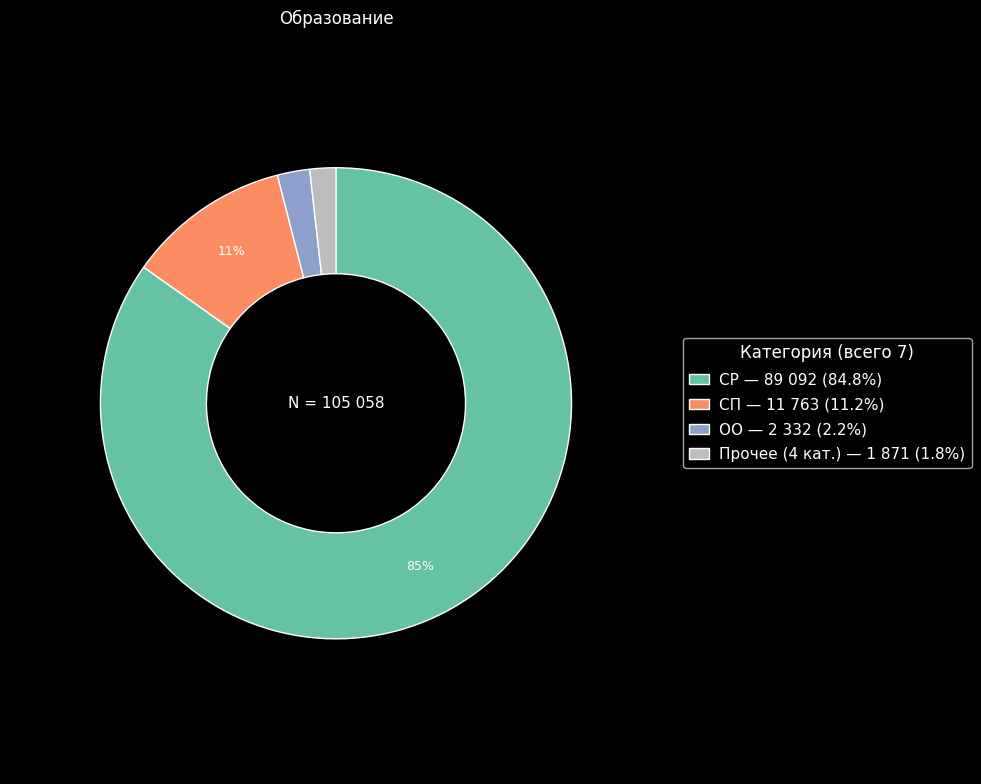

In [104]:
plot_categorical_pie(data, "Образование", "Образование", figsize=(10, 8))


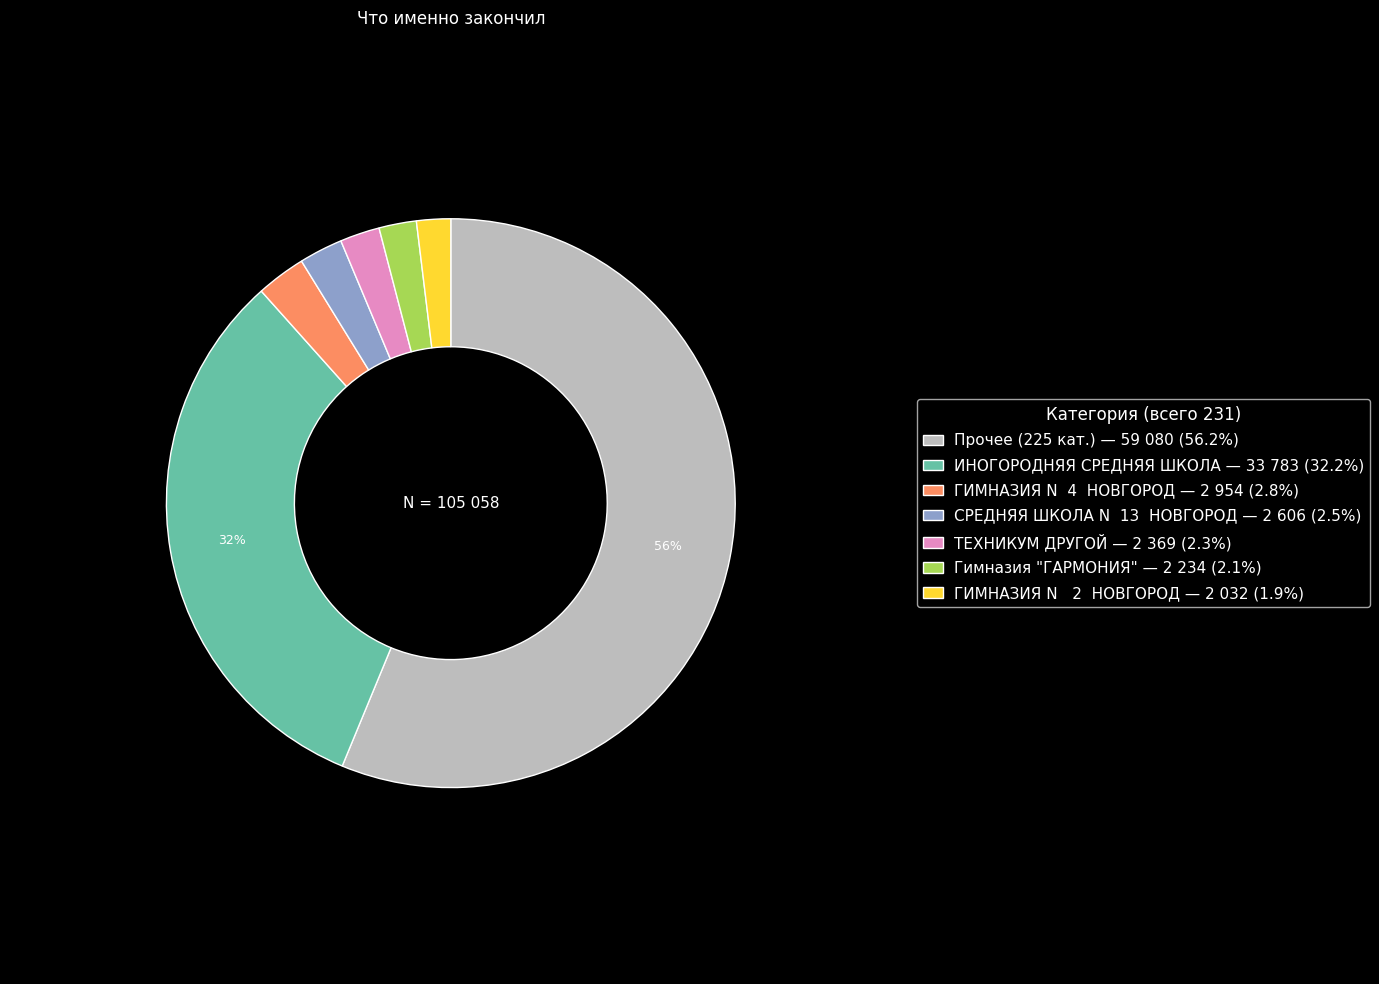

In [105]:
plot_categorical_pie(data, "Что именно закончил", "Что именно закончил", figsize=(14, 10))


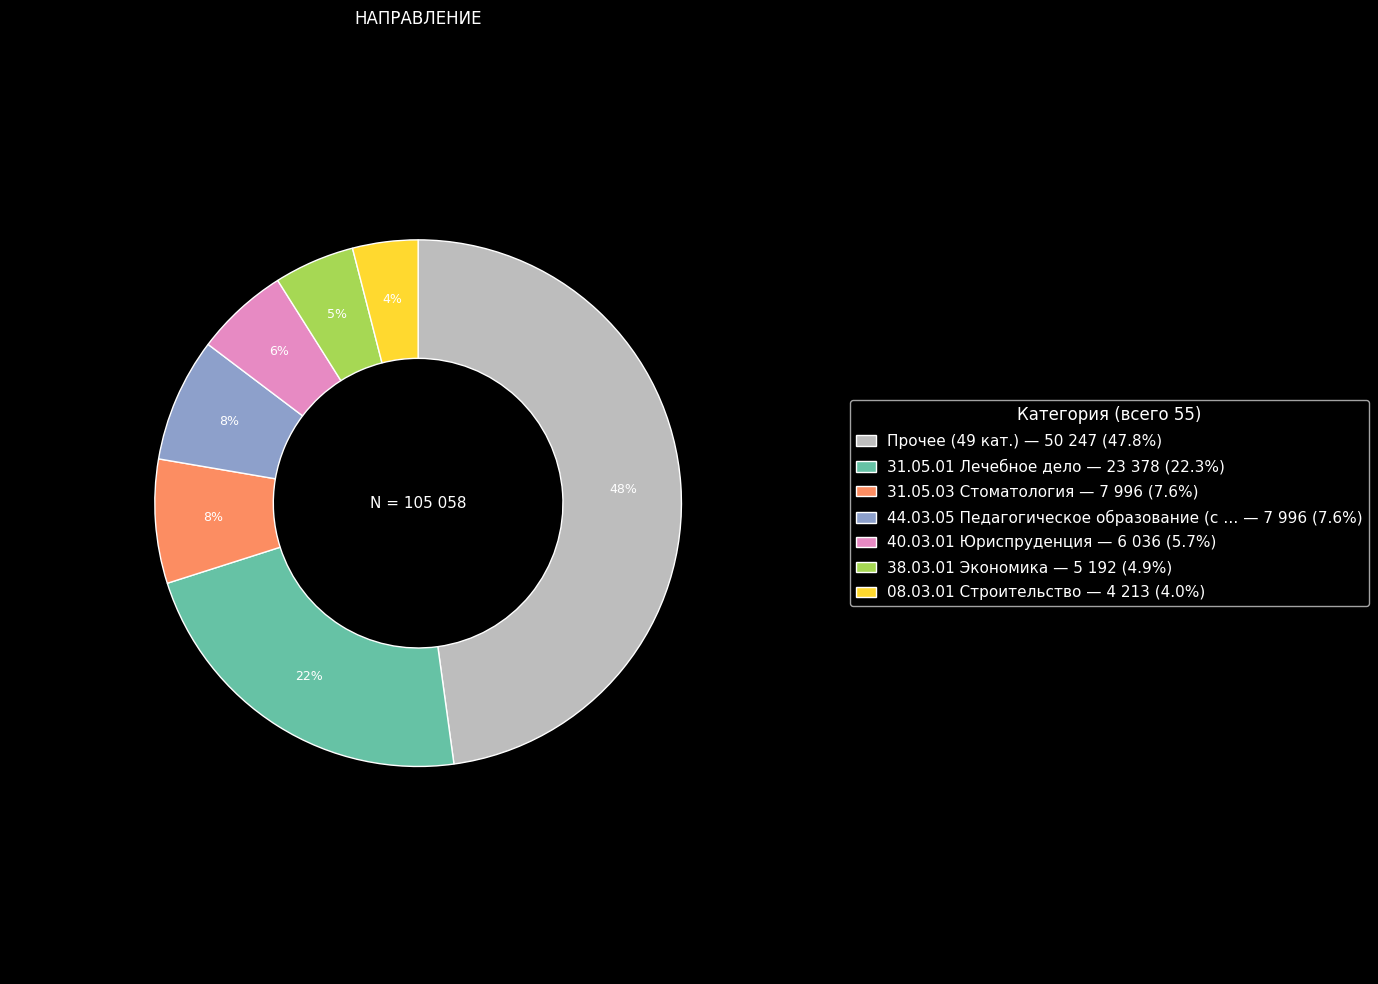

In [106]:
plot_categorical_pie(data, "НАПРАВЛЕНИЕ", "НАПРАВЛЕНИЕ", figsize=(14, 10))


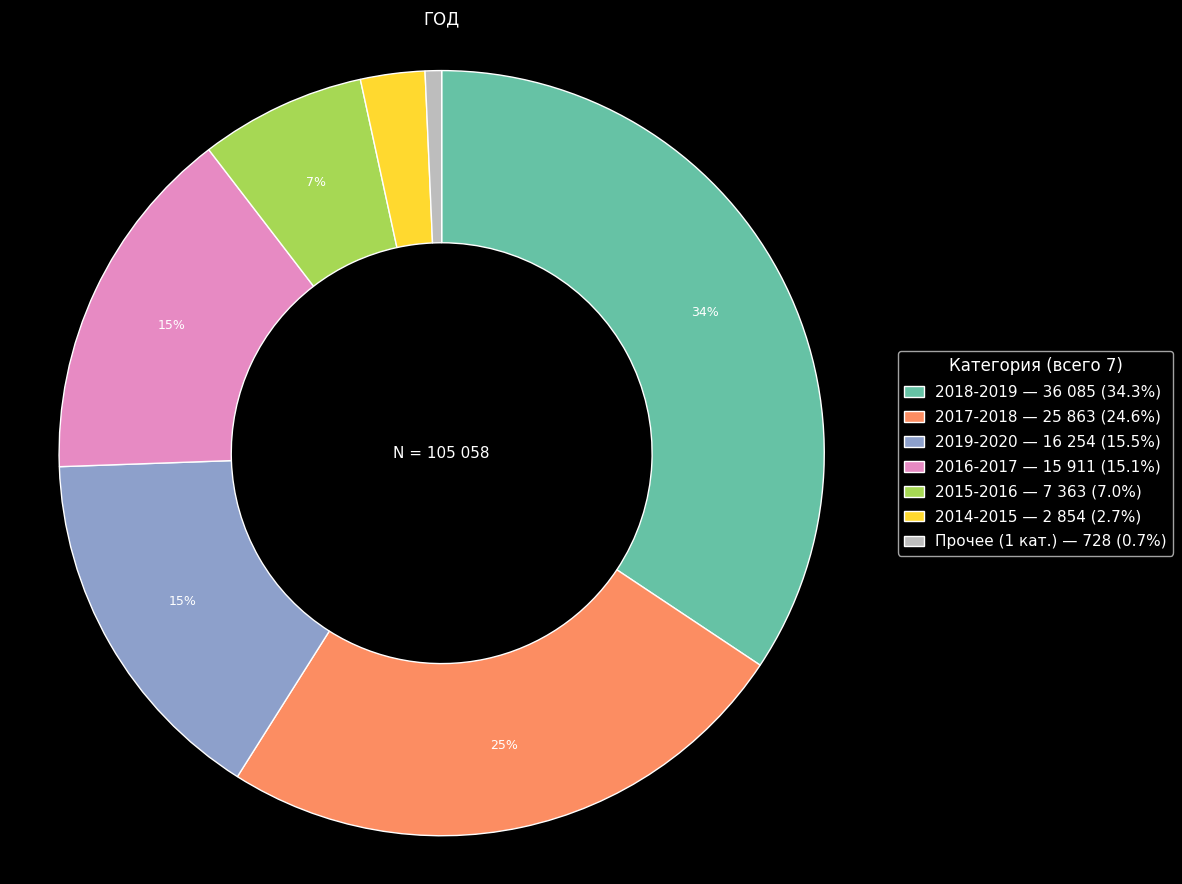

In [107]:
plot_categorical_pie(data, "ГОД", "ГОД", figsize=(12, 9))


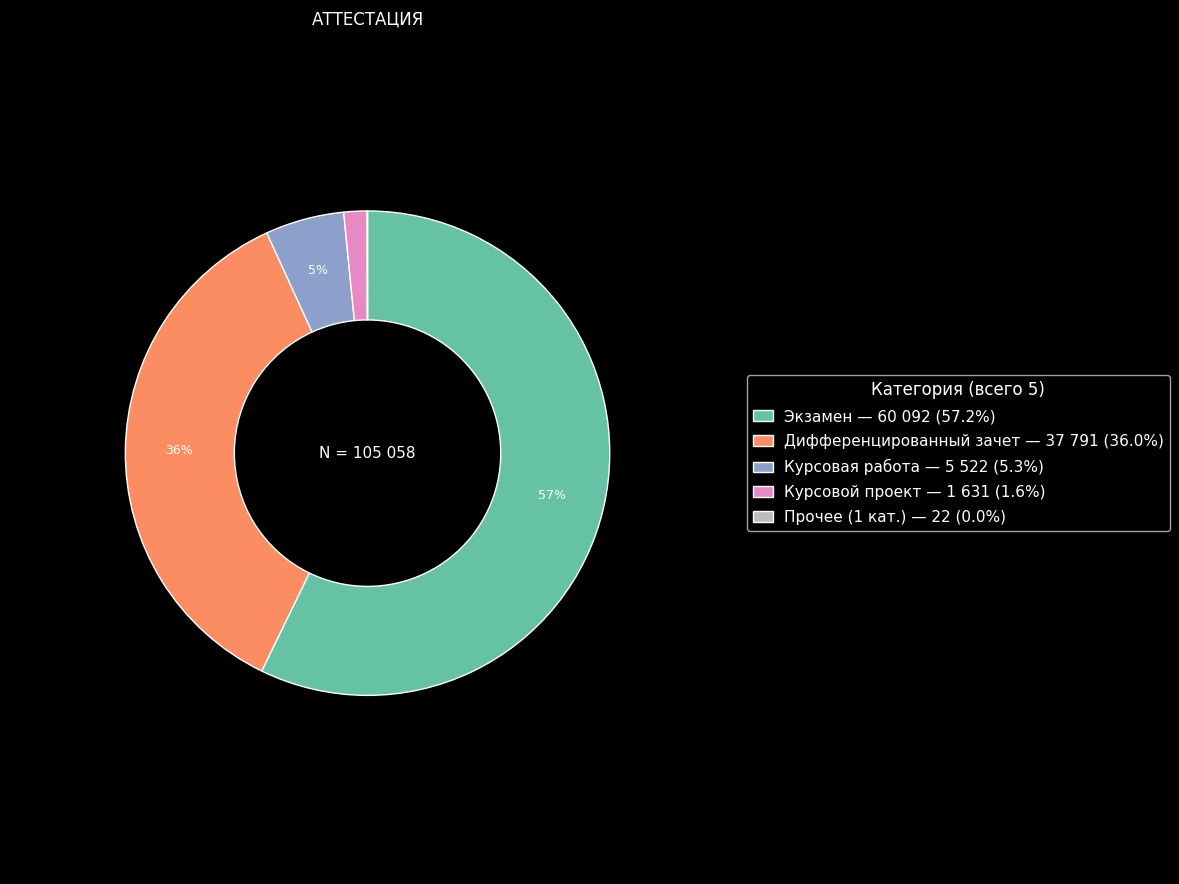

In [108]:
plot_categorical_pie(data, "АТТЕСТАЦИЯ", "АТТЕСТАЦИЯ", figsize=(12, 9))


In [109]:
data['ДИСЦИПЛИНА'].value_counts()

ДИСЦИПЛИНА
История                                                                                    3318
Философия                                                                                  3248
Иностранный язык                                                                           3165
Математика                                                                                 2650
Физика                                                                                     2003
                                                                                           ... 
Коммуникационный менеджмент                                                                   1
Государственное регулирование в отраслях (сельское хозяйство, охота и лесное хозяйство)       1
Проектирование уникальных зданий и сооружений                                                 1
Организация предпринимательской деятельности в агропромышленном комплексе                     1
Прогнозирование и стратегичес

In [110]:
data['ДИСЦИПЛИНА'].unique(), len(data['ДИСЦИПЛИНА'].unique())

(array(['Маркетинг',
        'Пропедевтика внутренних болезней, лучевая диагностика: пропедевтика внутренних болезней',
        'Химия', ...,
        'Практикум по культуре речевого общения (первый иностранный язык)',
        'Продвижение медиапроектов в интернете',
        'Прогнозирование и стратегическое планирование в агропромышленном комплексе'],
       shape=(1400,), dtype=object),
 1400)

## Посмотрим как признаки влияют друг на друга

In [111]:
for col in data.columns:
    if data[col].dtype == "object":
        print(col, data[col].dtype)

НАПРАВЛЕНИЕ object
ГОД object
АТТЕСТАЦИЯ object
ДИСЦИПЛИНА object
Пол object
Статус object
Категория обучения object
Форма обучения object
Образование object
Что именно закончил object


100%|██████████| 15/15 [00:00<00:00, 103.02it/s]


<Axes: >

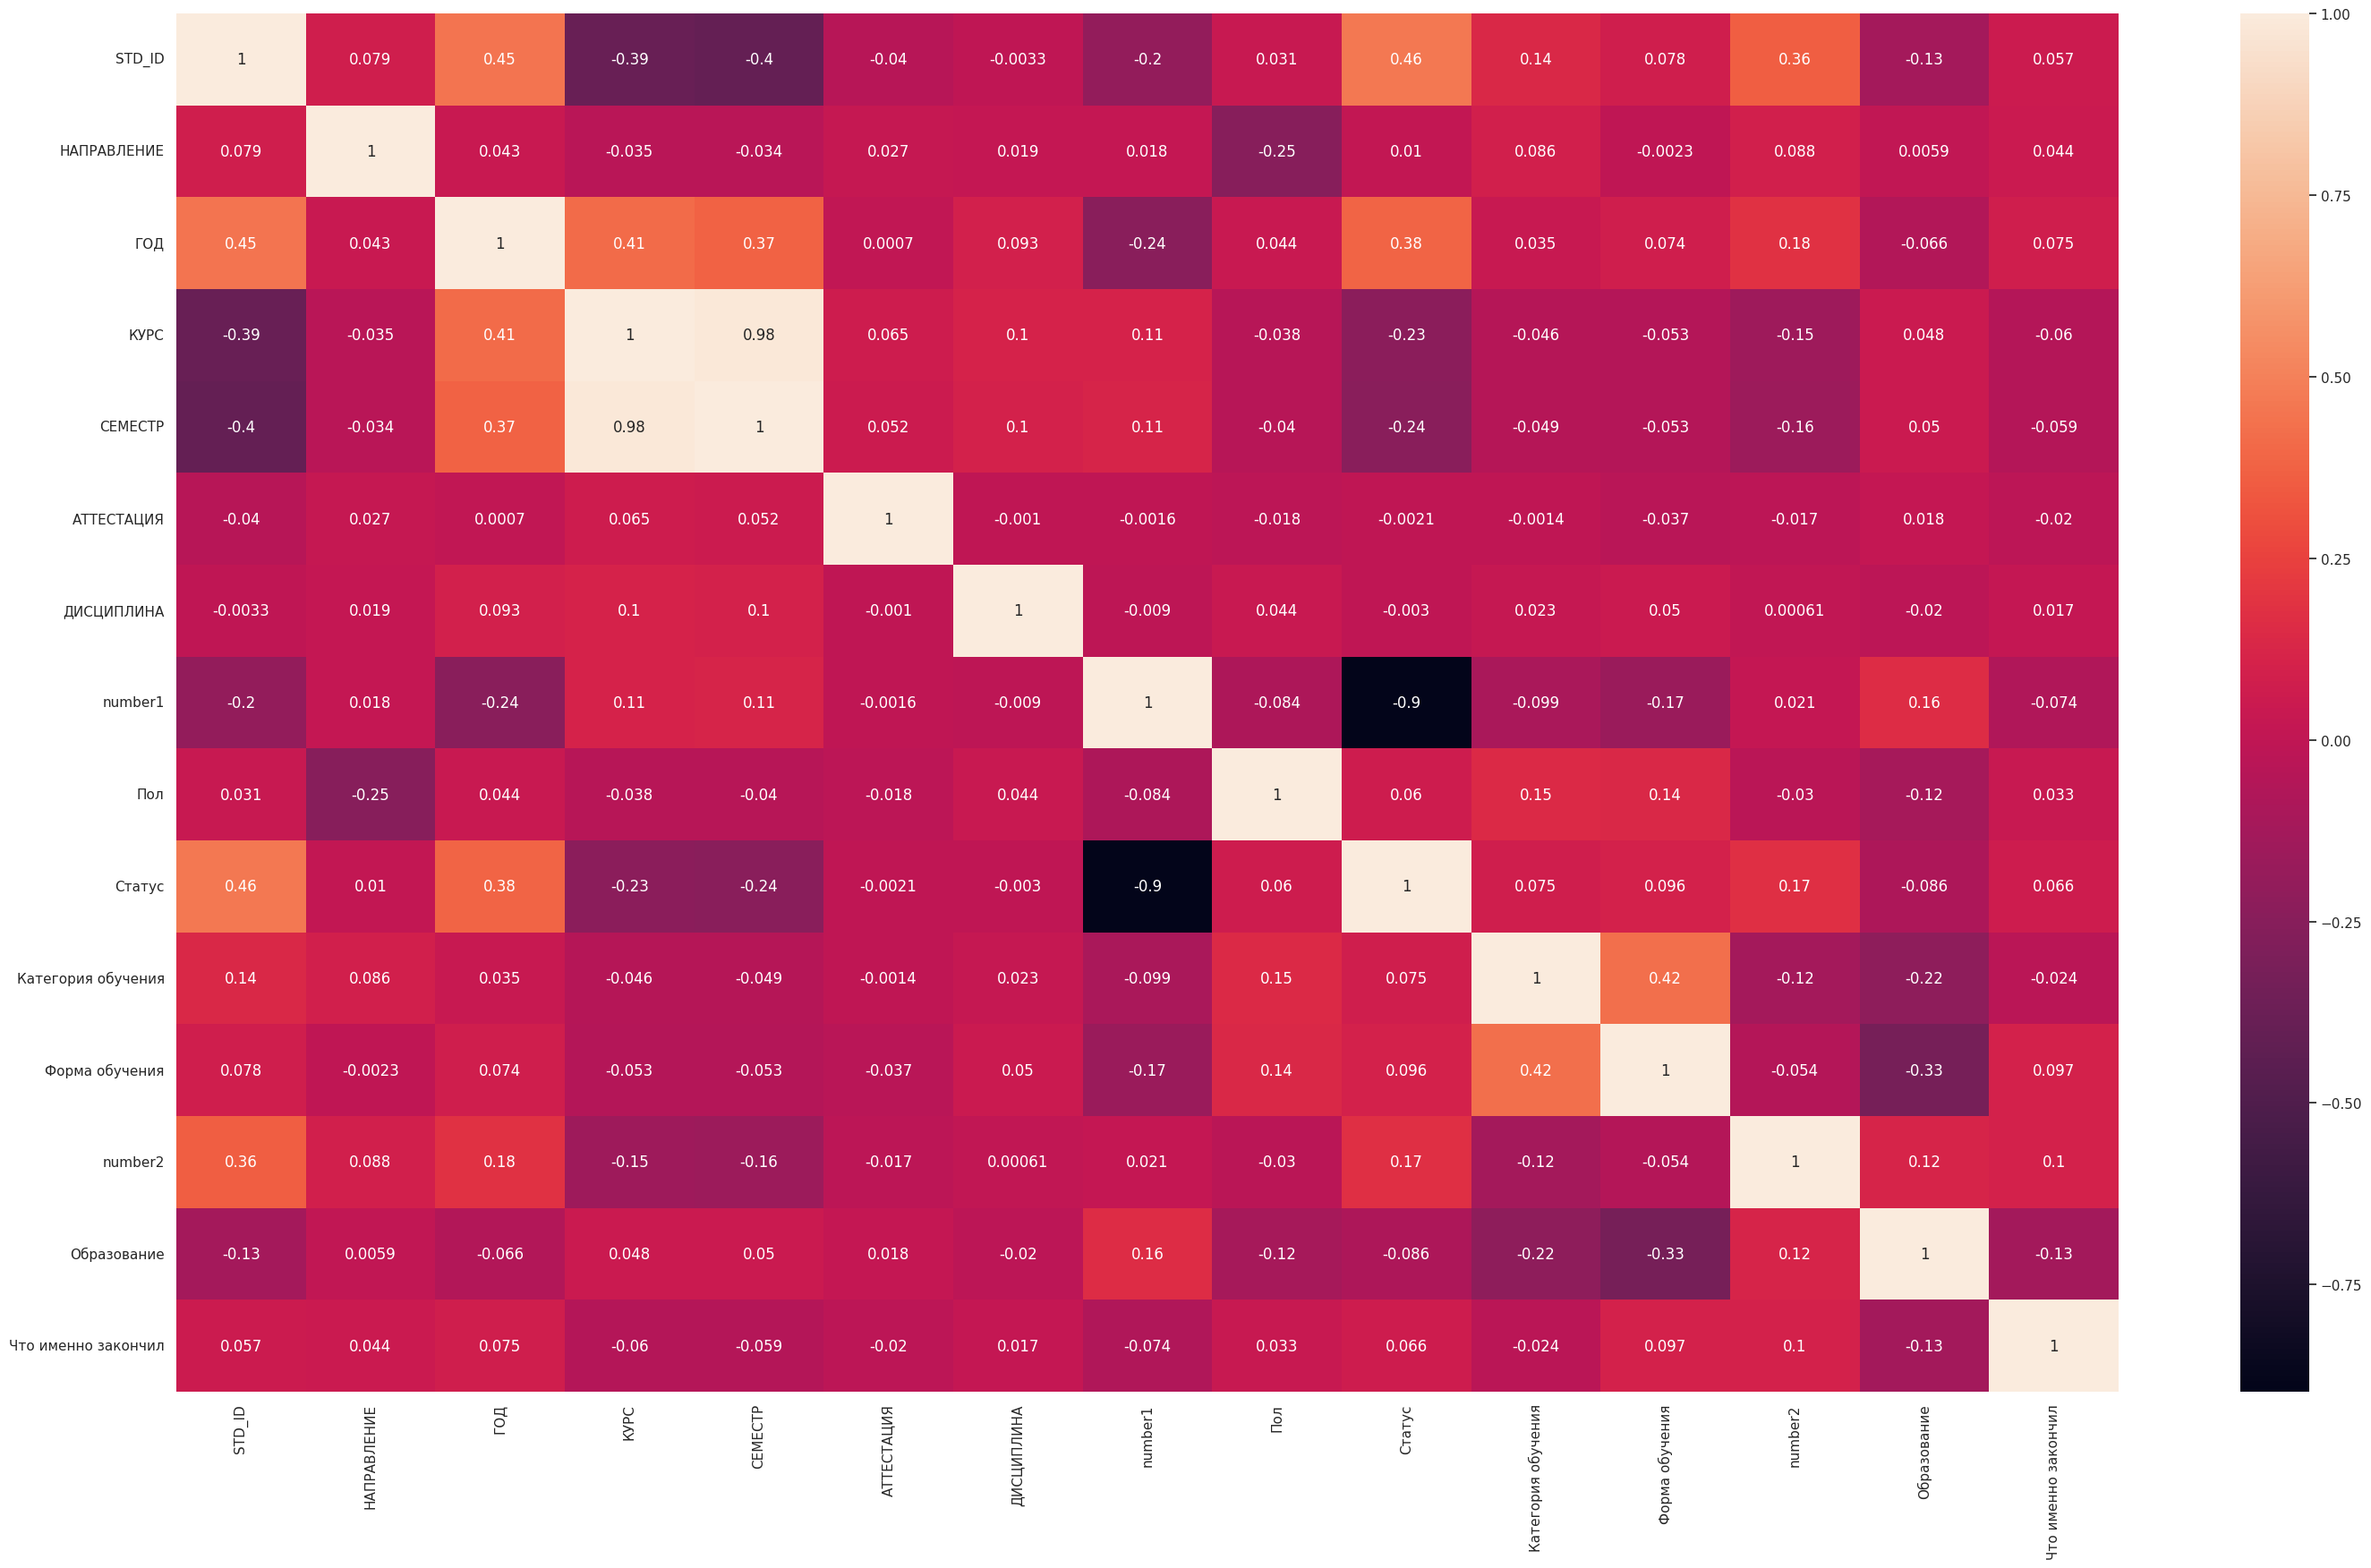

In [112]:
corr_data = data.copy()

for elem in tqdm(data.columns):
    if data[elem].to_numpy().dtype == object:
        corr_data[elem] = corr_data[elem].astype('category')
        corr_data[elem] = corr_data[elem].cat.codes

sns.set(rc={'figure.figsize': (35, 20)})

sns.heatmap(corr_data.corr(), annot=True)

In [113]:
data

,STD_ID,НАПРАВЛЕНИЕ,ГОД,КУРС,СЕМЕСТР,АТТЕСТАЦИЯ,ДИСЦИПЛИНА,number1,Пол,Статус,Категория обучения,Форма обучения,number2,Образование,Что именно закончил
0,175711,38.03.02 Менеджмент,2018-2019,2.0,4.0,Экзамен,Маркетинг,3989.0,М,СТ,БП,Д,5445.0,СР,"СРЕДНЯЯ ШКОЛА N 31, НОВГОРОД"
1,100647,31.05.01 Лечебное дело,2015-2016,3.0,5.0,Экзамен,"Пропедевтика внутренних болезней, лучевая диаг...",14025.0,Ж,ВЫП,ДОГ,Д,2668.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
2,199311,31.05.03 Стоматология,2019-2020,1.0,1.0,Экзамен,Химия,7212.0,Ж,СТ,БП,Д,11431.0,СР,"ГИМНАЗИЯ N 2, НОВГОРОД"
3,162002,38.03.02 Менеджмент,2017-2018,2.0,3.0,Экзамен,Статистика,3293.0,М,СТ,БП,Д,4981.0,СР,"Гимназия ""ГАРМОНИЯ"""
4,108384,31.05.01 Лечебное дело,2018-2019,5.0,9.0,Экзамен,Педиатрия,875.0,Ж,СТ,ДОГ,Д,2034.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105053,176141,40.03.01 Юриспруденция,2017-2018,1.0,2.0,Курсовая работа,Конституционное право,861.0,Ж,СТ,ДОГ,В,8613.0,СР,"МОУ СОШ N 1, СОЛЬЦЫ с филиалом в Куклино"
105054,182794,31.05.01 Лечебное дело,2018-2019,2.0,4.0,Экзамен,Нормальная физиология,3859.0,Ж,СТ,ДОГ,Д,5505.0,СР,ИНОГОРОДНЯЯ СРЕДНЯЯ ШКОЛА
105055,162391,31.05.01 Лечебное дело,2016-2017,1.0,2.0,Дифференцированный зачет,Иностранный язык,6989.0,Ж,СТ,БП,Д,4900.0,СР,"ГИМНАЗИЯ N 1, НОВГОРОД"
105056,202479,38.03.01 Экономика,2017-2018,1.0,1.0,Дифференцированный зачет,Информатика,4091.0,Ж,СТ,ДОГ,З,5466.0,СР,"Гимназия ""ГАРМОНИЯ"""


# Выбор алгоритма

In [114]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

CAT_COLS = ['НАПРАВЛЕНИЕ', 'ГОД', 'АТТЕСТАЦИЯ', 'ДИСЦИПЛИНА',
            'Пол', 'Статус', 'Категория обучения', 'Форма обучения',
            'Образование', 'Что именно закончил']
NUM_COLS = ['КУРС', 'СЕМЕСТР']  # number1 number2 убираем
HISTORY_COLS = ['stud_mean_grade', 'stud_count', 'discipline_mean_grade', 'direction_mean_grade']
FEATURES = CAT_COLS + NUM_COLS + HISTORY_COLS

Y = pd.read_csv('./onti-students-performance/y_train.csv')['mark'].loc[data.index].reset_index(drop=True)
data_r = data.reset_index(drop=True)

train_idx, valid_idx = train_test_split(np.arange(len(data_r)), test_size=0.1, random_state=42)


def oof_target_mean(df, key, target, n_splits=5, seed=42):
    out = pd.Series(np.nan, index=df.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr, va in kf.split(df):
        means = df.iloc[tr].groupby(key)[target.name].mean()
        out.iloc[va] = df.iloc[va][key].map(means).values
    return out


train_df = data_r.iloc[train_idx].copy()
train_df['mark'] = Y.iloc[train_idx].values

global_mean = train_df['mark'].mean()

train_df['stud_mean_grade'] = oof_target_mean(train_df, 'STD_ID', train_df['mark'])
train_df['discipline_mean_grade'] = oof_target_mean(train_df, 'ДИСЦИПЛИНА', train_df['mark'])
train_df['direction_mean_grade'] = oof_target_mean(train_df, 'НАПРАВЛЕНИЕ', train_df['mark'])
train_df['stud_count'] = train_df.groupby('STD_ID')['STD_ID'].transform('count') - 1
for c in ['stud_mean_grade', 'discipline_mean_grade', 'direction_mean_grade']:
    train_df[c] = train_df[c].fillna(global_mean)

stud_full = train_df.groupby('STD_ID')['mark'].mean()
disc_full = train_df.groupby('ДИСЦИПЛИНА')['mark'].mean()
dir_full = train_df.groupby('НАПРАВЛЕНИЕ')['mark'].mean()
stud_count_full = train_df.groupby('STD_ID').size()

valid_df = data_r.iloc[valid_idx].copy()
valid_df['stud_mean_grade'] = valid_df['STD_ID'].map(stud_full).fillna(global_mean)
valid_df['discipline_mean_grade'] = valid_df['ДИСЦИПЛИНА'].map(disc_full).fillna(global_mean)
valid_df['direction_mean_grade'] = valid_df['НАПРАВЛЕНИЕ'].map(dir_full).fillna(global_mean)
valid_df['stud_count'] = valid_df['STD_ID'].map(stud_count_full).fillna(0)

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoder.fit(train_df[CAT_COLS])

X_train = train_df[FEATURES].copy()
X_train[CAT_COLS] = encoder.transform(train_df[CAT_COLS])
X_valid = valid_df[FEATURES].copy()
X_valid[CAT_COLS] = encoder.transform(valid_df[CAT_COLS])

X_train = X_train.reset_index(drop=True)
X_valid = X_valid.reset_index(drop=True)
Y_train = Y.iloc[train_idx].reset_index(drop=True)
Y_valid = Y.iloc[valid_idx].reset_index(drop=True)

scale_cols = NUM_COLS + HISTORY_COLS
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_valid_scaled = X_valid.copy()
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_valid_scaled[scale_cols] = scaler.transform(X_valid[scale_cols])

n_warm = valid_df['STD_ID'].isin(stud_full.index).sum()
print(f'train: {len(X_train)}, valid: {len(X_valid)}')
print(f'global mean grade: {global_mean:.3f}')
print(f'warm (студент известен) в valid: {n_warm} / {len(X_valid)} ({n_warm/len(X_valid):.1%})')
X_train.head()

train: 94552, valid: 10506
global mean grade: 4.184
warm (студент известен) в valid: 10503 / 10506 (100.0%)


,НАПРАВЛЕНИЕ,ГОД,АТТЕСТАЦИЯ,ДИСЦИПЛИНА,Пол,Статус,Категория обучения,Форма обучения,Образование,Что именно закончил,КУРС,СЕМЕСТР,stud_mean_grade,stud_count,discipline_mean_grade,direction_mean_grade
0,35.0,5.0,0.0,29.0,0.0,1.0,1.0,2.0,6.0,23.0,4.0,8.0,4.437500,20,4.121212,4.107634
1,33.0,5.0,4.0,719.0,0.0,1.0,1.0,2.0,6.0,13.0,1.0,2.0,5.000000,8,4.200000,4.736842
2,40.0,6.0,4.0,270.0,0.0,1.0,1.0,2.0,6.0,37.0,1.0,1.0,4.000000,3,3.918033,3.958343
3,44.0,5.0,4.0,1139.0,0.0,1.0,0.0,1.0,6.0,188.0,2.0,4.0,4.636364,15,4.474227,4.279893
4,24.0,4.0,4.0,945.0,0.0,1.0,0.0,1.0,6.0,162.0,3.0,6.0,4.347826,28,4.288110,4.206130


In [115]:
X_valid_scaled

,НАПРАВЛЕНИЕ,ГОД,АТТЕСТАЦИЯ,ДИСЦИПЛИНА,Пол,Статус,Категория обучения,Форма обучения,Образование,Что именно закончил,КУРС,СЕМЕСТР,stud_mean_grade,stud_count,discipline_mean_grade,direction_mean_grade
0,25.0,5.0,0.0,749.0,1.0,1.0,0.0,1.0,6.0,15.0,1.421705,1.251842,1.496037,1.275594,1.060081,-0.324829
1,17.0,6.0,4.0,1199.0,1.0,1.0,1.0,2.0,6.0,146.0,1.421705,1.251842,-0.689008,0.288842,-0.151779,-2.067221
2,47.0,2.0,0.0,260.0,0.0,1.0,0.0,1.0,6.0,83.0,-1.020892,-1.198322,0.490940,0.979569,0.013335,0.998592
3,36.0,5.0,0.0,146.0,0.0,0.0,0.0,1.0,6.0,161.0,1.421705,1.251842,0.645570,0.880893,2.473918,-0.139576
4,44.0,4.0,4.0,1137.0,0.0,1.0,1.0,2.0,6.0,179.0,-0.206693,-0.381601,-0.374990,-1.487313,0.967371,0.469220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10501,40.0,4.0,0.0,840.0,1.0,1.0,1.0,2.0,4.0,58.0,-0.206693,0.026760,-1.310503,0.091491,1.236496,-1.187925
10502,44.0,6.0,4.0,1072.0,1.0,1.0,1.0,2.0,6.0,183.0,-0.206693,-0.381601,-1.905829,-1.882014,0.082494,0.469220
10503,37.0,3.0,2.0,407.0,1.0,1.0,1.0,2.0,5.0,145.0,-0.206693,-0.381601,-0.656523,0.584867,-0.905307,-0.899978
10504,50.0,6.0,0.0,800.0,0.0,0.0,1.0,0.0,6.0,37.0,0.607506,0.435121,1.509121,-0.993937,1.617713,3.282569


In [120]:
X_valid

,НАПРАВЛЕНИЕ,ГОД,АТТЕСТАЦИЯ,ДИСЦИПЛИНА,Пол,Статус,Категория обучения,Форма обучения,Образование,Что именно закончил,КУРС,СЕМЕСТР,stud_mean_grade,stud_count,discipline_mean_grade,direction_mean_grade
0,25.0,5.0,0.0,749.0,1.0,1.0,0.0,1.0,6.0,15.0,4.0,7.0,4.916667,36.0,4.533333,4.120256
1,17.0,6.0,4.0,1199.0,1.0,1.0,1.0,2.0,6.0,146.0,4.0,7.0,3.846154,26.0,4.133333,3.780931
2,47.0,2.0,0.0,260.0,0.0,1.0,0.0,1.0,6.0,83.0,1.0,1.0,4.424242,33.0,4.187832,4.377988
3,36.0,5.0,0.0,146.0,0.0,0.0,0.0,1.0,6.0,161.0,4.0,7.0,4.500000,32.0,5.000000,4.156333
4,44.0,4.0,4.0,1137.0,0.0,1.0,1.0,2.0,6.0,179.0,2.0,3.0,4.000000,8.0,4.502732,4.274894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10501,40.0,4.0,0.0,840.0,1.0,1.0,1.0,2.0,4.0,58.0,2.0,4.0,3.541667,24.0,4.591563,3.952171
10502,44.0,6.0,4.0,1072.0,1.0,1.0,1.0,2.0,6.0,183.0,2.0,3.0,3.250000,4.0,4.210660,4.274894
10503,37.0,3.0,2.0,407.0,1.0,1.0,1.0,2.0,5.0,145.0,2.0,3.0,3.862069,29.0,3.884615,4.008247
10504,50.0,6.0,0.0,800.0,0.0,0.0,1.0,0.0,6.0,37.0,3.0,5.0,4.923077,13.0,4.717391,4.822785


## LinearRegression

In [132]:
model_LR = LinearRegression()

model_LR.fit(X_train, Y_train)

pred_model_LR = [5 if i > 5 else abs(i) for i in model_LR.predict(X_valid)]

## SGDRegressor

In [133]:
model_SGDR = SGDRegressor()

model_SGDR.fit(X_train_scaled, Y_train)

pred_model_SGDR = [5 if i > 5 else abs(i) for i in model_SGDR.predict(X_valid_scaled)]

## GradientBoostingRegressor

In [124]:
model_GBR = GradientBoostingRegressor()

model_GBR.fit(X_train, Y_train)

pred_model_GBR = [5 if i > 5 else abs(i) for i in model_GBR.predict(X_valid)]

## RandomForestRegressor

In [49]:
model_RFR = RandomForestRegressor(random_state=42)

model_RFR.fit(X_train, Y_train)

pred_model_RFR = [5 if i > 5 else abs(i) for i in model_RFR.predict(X_valid)]

## MLPRegressor

In [134]:
model_MLPR = MLPRegressor()

model_MLPR.fit(X_train_scaled, Y_train)

pred_model_MLPR = [5 if i > 5 else abs(i) for i in model_MLPR.predict(X_valid_scaled)]

## Результаты

In [135]:
comparison_table = pd.DataFrame(
    result_table(
        [
            pred_model_LR,
            pred_model_SGDR,
            pred_model_GBR,
            pred_model_RFR,
            pred_model_MLPR
        ],
        Y_valid,
        subcol='models',
        valueSubCol=['LR', 'SGDR', 'GBR', 'RFR', 'MLPR']
    )
)
comparison_table

,models,mean_squared_error,mean_absolute_error,median_absolute_error,mean_absolute_percentage_error,r2_score
0,LR,5.565227e-01,4.490496e-01,3.980935e-01,1.141003e-01,4.570486e-01
1,SGDR,1.727718e+13,1.485268e+13,1.456138e+13,3.683165e+12,-5.232883e+26
2,GBR,5.468555e-01,4.445271e-01,3.908393e-01,1.128287e-01,4.757478e-01
3,RFR,5.348424e-01,4.213161e-01,3.500000e-01,1.066792e-01,4.985279e-01
4,MLPR,5.882252e-01,4.724666e-01,4.156325e-01,1.178294e-01,3.934278e-01


In [136]:
comparison_table[comparison_table['r2_score'] == comparison_table['r2_score'].max()]

,models,mean_squared_error,mean_absolute_error,median_absolute_error,mean_absolute_percentage_error,r2_score
3,RFR,0.534842,0.421316,0.35,0.106679,0.498528


In [137]:
sorted(comparison_table['r2_score'])

[-5.232883457801266e+26,
 0.3934278229361693,
 0.457048644481409,
 0.47574778409055585,
 0.49852785136717326]

# Подберем параметры для лучшей модели

In [140]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [200, 400, 600],
    'max_depth': [None, 15, 20, 30],
    'min_samples_leaf': [1, 3, 5],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 0.5, 0.7],
}

rf = RandomForestRegressor(n_jobs=-1, random_state=42)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring='r2',
    cv=3,
    n_jobs=1,
    random_state=42,
    verbose=1,
)
search.fit(X_train, Y_train)

print('Лучшие параметры:', search.best_params_)
print(f'Лучший CV R²:    {search.best_score_:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Лучшие параметры: {'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Лучший CV R²:    0.5106


In [141]:
model_RFR = search.best_estimator_

pred_model_RFR_tuned = [5 if i > 5 else abs(i) for i in model_RFR.predict(X_valid)]

In [142]:
import numpy as np

valid_stud_ids = data_r['STD_ID'].iloc[valid_idx].reset_index(drop=True)
warm_mask = valid_stud_ids.isin(stud_full.index).values
cold_mask = ~warm_mask

pred_arr = np.array(pred_model_RFR_tuned)
y_arr = np.array(Y_valid)

print('Общая метрика на holdout')
result_pred(pred_arr, y_arr)

print(f'\nWarm start (студент известен): {warm_mask.sum()} записей')
if warm_mask.sum() > 0:
    result_pred(pred_arr[warm_mask], y_arr[warm_mask])

print(f'\nCold start (новый студент): {cold_mask.sum()} записей')
if cold_mask.sum() > 0:
    result_pred(pred_arr[cold_mask], y_arr[cold_mask])
else:
    print('Нет cold записей (все студенты в valid встречались в train).')

print(f'\nДоля warm в holdout: {warm_mask.mean():.1%}')

Общая метрика на holdout
mean_squared_error: 0.5206080312790492
mean_absolute_error: 0.4137556254550823
median_absolute_error: 0.34503025147007005
mean_absolute_percentage_error: 0.1048335267309678
r2_score: 0.5248651407265938

Warm start (студент известен): 10503 записей
mean_squared_error: 0.5206635893801436
mean_absolute_error: 0.4138013524265293
median_absolute_error: 0.3451208381030626
mean_absolute_percentage_error: 0.10484535682297756
r2_score: 0.5248910046272033

Cold start (новый студент): 3 записей
mean_squared_error: 0.26171761933911186
mean_absolute_error: 0.25366549841877184
median_absolute_error: 0.2522837571962544
mean_absolute_percentage_error: 0.06341637460469296
r2_score: 0.0

Доля warm в holdout: 100.0%


# Предскажем тест

In [143]:
testData = pd.read_csv('./onti-students-performance/X_test.csv').drop(columns=['Unnamed: 0'])

In [144]:
testData

,STD_ID,НАПРАВЛЕНИЕ,ГОД,КУРС,СЕМЕСТР,АТТЕСТАЦИЯ,ДИСЦИПЛИНА
0,163261,35.03.04 Агрономия,2018-2019,3.0,5.0,Дифференцированный зачет,История
1,162990,23.03.03 Эксплуатация транспортно-технологичес...,2019-2020,4.0,7.0,Экзамен,Сертификация и лицензирование в сфере производ...
2,192595,40.03.01 Юриспруденция,2018-2019,1.0,2.0,Экзамен,История государства и права России
3,198675,38.03.01 Экономика,2018-2019,2.0,3.0,Дифференцированный зачет,Иностранный язык в сфере профессиональной комм...
4,162111,44.03.05 Педагогическое образование (с двумя п...,2018-2019,3.0,6.0,Экзамен,Физическая химия
...,...,...,...,...,...,...,...
26260,164804,31.05.01 Лечебное дело,2019-2020,4.0,7.0,Экзамен,"Факультетская хирургия, урология"
26261,170508,40.03.01 Юриспруденция,2019-2020,4.0,7.0,Дифференцированный зачет,Арбитражный процесс
26262,178316,31.05.03 Стоматология,2017-2018,1.0,2.0,Экзамен,"Гистология, эмбриология, цитология - гистологи..."
26263,186542,46.03.01 История,2019-2020,2.0,3.0,Дифференцированный зачет,Иностранный язык


In [145]:
testData = testData.merge(studs_info, how='left', on='STD_ID')

for col in NUM_COLS:
    testData[col] = testData[col].fillna(train_df[col].mean())
for col in CAT_COLS:
    testData[col] = testData[col].fillna(train_df[col].mode()[0])

testData['stud_mean_grade'] = testData['STD_ID'].map(stud_full).fillna(global_mean)
testData['discipline_mean_grade'] = testData['ДИСЦИПЛИНА'].map(disc_full).fillna(global_mean)
testData['direction_mean_grade'] = testData['НАПРАВЛЕНИЕ'].map(dir_full).fillna(global_mean)
testData['stud_count'] = testData['STD_ID'].map(stud_count_full).fillna(0)

testData_X = testData[FEATURES].copy()
testData_X[CAT_COLS] = encoder.transform(testData_X[CAT_COLS])
print(f'test: {len(testData_X)}, известных студентов: {testData["STD_ID"].isin(stud_full.index).sum()}')

test: 26265, известных студентов: 26253


In [146]:
testData.isnull().sum()

STD_ID                   0
НАПРАВЛЕНИЕ              0
ГОД                      0
КУРС                     0
СЕМЕСТР                  0
АТТЕСТАЦИЯ               0
ДИСЦИПЛИНА               0
number1                  0
Пол                      0
Статус                   0
Категория обучения       0
Форма обучения           0
number2                  0
Образование              0
Что именно закончил      0
stud_mean_grade          0
discipline_mean_grade    0
direction_mean_grade     0
stud_count               0
dtype: int64

In [147]:
import joblib
from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error

Y_predTest = [5 if i > 5 else abs(i) for i in model_RFR.predict(testData_X)]

ART_DIR = Path('./artifacts')
ART_DIR.mkdir(exist_ok=True)

categories = {col: list(map(str, c)) for col, c in zip(CAT_COLS, encoder.categories_)}
studs_for_meta = data.drop_duplicates(['STD_ID'])[
    ['STD_ID', 'Пол', 'Статус', 'Категория обучения', 'Форма обучения',
     'Образование', 'Что именно закончил']
]

joblib.dump(model_RFR, ART_DIR / 'model.pkl')
joblib.dump(encoder, ART_DIR / 'encoder.pkl')
joblib.dump({
    'model_type': 'sklearn',
    'best_name': 'RandomForest (tuned, with history features)',
    'cat_cols': CAT_COLS,
    'num_cols': NUM_COLS,
    'history_cols': HISTORY_COLS,
    'features': FEATURES,
    'categories': categories,
    'studs_info': studs_for_meta.to_dict(orient='records'),
    'global_mean': float(global_mean),
    'stud_full': stud_full.to_dict(), # warm start: средняя оценка студента
    'stud_count': stud_count_full.to_dict(),
    'disc_full': disc_full.to_dict(), # средняя по дисциплине
    'dir_full': dir_full.to_dict(), # средняя по направлению
    'metrics': {
        'r2_score': float(r2_score(Y_valid, pred_model_RFR_tuned)),
        'mean_absolute_error': float(mean_absolute_error(Y_valid, pred_model_RFR_tuned)),
    },
}, ART_DIR / 'meta.pkl')
print(f'Saved. R²={r2_score(Y_valid, pred_model_RFR_tuned):.4f}, MAE={mean_absolute_error(Y_valid, pred_model_RFR_tuned):.4f}')

Saved. R²=0.5249, MAE=0.4138


In [148]:
submission = pd.read_csv('./onti-students-performance/sample_submission.csv')

In [149]:
submission['mark'] = Y_predTest

In [150]:
submission.to_csv('sub.csv', index=False)

In [151]:
pd.read_csv('sub.csv')

,index,mark
0,56065,4.061822
1,304637,4.174500
2,177437,3.856867
3,222396,4.184371
4,271996,3.935712
...,...,...
26260,49838,4.403980
26261,273753,3.603899
26262,35426,3.415235
26263,160476,4.127636
